In [1]:
# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Colormap, LinearSegmentedColormap

# delicate, low-contrast blue palette (very light -> soft medium blue)
SOFT_BLUE = LinearSegmentedColormap.from_list(
    "soft_blue",
    ["#f7fbff", "#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#4292c6"],
)
# gentle diverging palette for difference maps (muted blue <-> muted red)
SOFT_DIVERGING = sns.color_palette("vlag", as_cmap=True)


def _as_aa_frame(matrix) -> pd.DataFrame:
    """Wrap a square matrix in a DataFrame labelled by the 20 standard amino acids."""
    if isinstance(matrix, pd.DataFrame):
        return matrix.copy()
    matrix = np.asarray(matrix)
    n = matrix.shape[0]
    labels = ALL_AA if n == len(ALL_AA) else [f"AA{i + 1}" for i in range(n)]
    return pd.DataFrame(matrix, index=labels, columns=labels)


def plot_change_matrix(
    matrix,
    classification: str | None = "chemical_type",
    cmap=SOFT_BLUE,
    title: str | None = None,
    mask_diagonal: bool = True,
    annot: bool = False,
    vmin: float | None = None,
    vmax: float | None = None,
    figsize: tuple = (9, 8),
    group_colors: dict | None = None,
    cbar_label: str | None = None,
    return_fig: bool = False,
):
    """Smooth amino-acid x amino-acid heatmap.

    When ``classification`` is a key of ``AMINO_ACID_CLASSES`` the axes are sorted by
    group (each AA assigned to the first group it belongs to) and the groups are marked
    with separator lines, colored bars and labels on both axes. The self->self diagonal
    is masked by default.
    """
    df = _as_aa_frame(matrix)
    aas = list(df.index)

    group_sizes: list[int] = []
    group_names: list[str] = []
    if classification is not None:
        if classification not in AMINO_ACID_CLASSES:
            raise ValueError(f"Unknown classification: {classification}")
        groups = AMINO_ACID_CLASSES[classification]
        sorted_aa: list[str] = []
        assigned: set[str] = set()
        for gname, members in groups.items():
            present = [aa for aa in aas if aa in members and aa not in assigned]
            if present:
                sorted_aa.extend(present)
                assigned.update(present)
                group_sizes.append(len(present))
                group_names.append(gname)
        sorted_aa.extend([aa for aa in aas if aa not in assigned])
        df = df.loc[sorted_aa, sorted_aa]

    mask = df.isna()
    if mask_diagonal:
        diag = np.zeros(df.shape, dtype=bool)
        np.fill_diagonal(diag, True)
        mask = mask | diag

    base_cmap = (cmap if isinstance(cmap, Colormap) else plt.get_cmap(cmap)).copy()
    base_cmap.set_bad(color="#ececec")

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df,
        cmap=base_cmap,
        mask=mask,
        square=True,
        linewidths=0.5,
        linecolor="white",
        vmin=vmin,
        vmax=vmax,
        annot=annot,
        fmt=".2f",
        annot_kws={"fontsize": 7},
        cbar_kws={"shrink": 0.7, "aspect": 25, "pad": 0.02, "label": cbar_label or ""},
        ax=ax,
    )
    ax.set_title(
        title or f"AA -> AA change matrix ({classification})",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("To amino acid", fontsize=11)
    ax.set_ylabel("From amino acid", fontsize=11)
    ax.tick_params(axis="both", labelsize=9, length=0)
    plt.setp(ax.get_yticklabels(), rotation=0)
    plt.setp(ax.get_xticklabels(), rotation=0)

    # === group separators + colored bars + labels (axes coordinates) ===
    if group_sizes:
        boundaries = np.cumsum(group_sizes)
        for b in boundaries[:-1]:
            ax.axhline(b, color="#9aa0a6", lw=1.0)
            ax.axvline(b, color="#9aa0a6", lw=1.0)

        total = len(df)
        mids = (boundaries - np.array(group_sizes) / 2) / total
        sizes_ax = np.array(group_sizes) / total
        if group_colors is None:
            palette = sns.color_palette("Set2", len(group_names))
            group_colors = {g: palette[i] for i, g in enumerate(group_names)}

        bar_t = 0.025
        y_gap, x_gap, lab_gap = 0.045, 0.06, 0.012
        for mid, gname, gsize in zip(mids, group_names, sizes_ax):
            col = group_colors.get(gname, "lightgray")
            y = 1.0 - mid  # axes y is bottom-up; heatmap rows are top-down
            # y-axis (left) bar + label
            ax.add_patch(
                plt.Rectangle(
                    (-(y_gap + bar_t), y - gsize / 2), bar_t, gsize,
                    transform=ax.transAxes, clip_on=False, color=col,
                )
            )
            ax.text(
                -(y_gap + bar_t) - lab_gap, y, gname, transform=ax.transAxes,
                rotation=90, ha="center", va="center", fontsize=9,
            )
            # x-axis (bottom) bar + label
            ax.add_patch(
                plt.Rectangle(
                    (mid - gsize / 2, -(x_gap + bar_t)), gsize, bar_t,
                    transform=ax.transAxes, clip_on=False, color=col,
                )
            )
            ax.text(
                mid, -(x_gap + bar_t) - lab_gap, gname, transform=ax.transAxes,
                rotation=90, ha="center", va="top", fontsize=9,
            )

        # keep the y-axis title clear of the group-name labels (axes-fraction coords)
        ax.yaxis.set_label_coords(-(y_gap + bar_t) - 0.06, 0.5)

    if return_fig:
        return fig, ax
    plt.show()
    return None


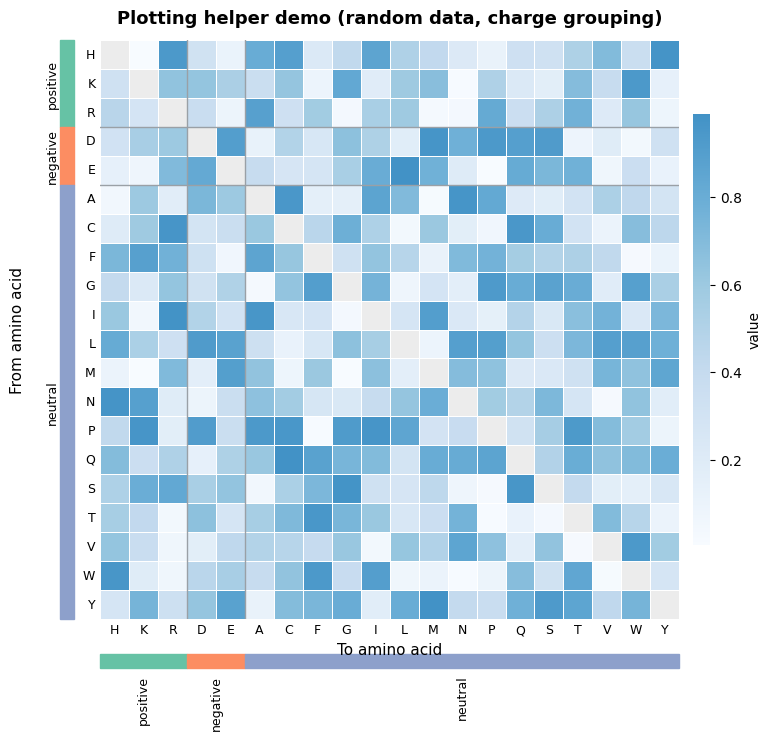

In [3]:
# quick sanity check of the plotting helper on random data
np.random.seed(42)
random_data = np.random.rand(20, 20)
plot_change_matrix(
    random_data,
    classification="charge",
    title="Plotting helper demo (random data, charge grouping)",
    cbar_label="value",
)


In [4]:
# === Locate the single-position-mutation datasets ===
from pathlib import Path


def find_project_root(marker: str = "pep-compass", start: Path | None = None) -> Path:
    """Walk up from `start` (CWD by default) to the `pep-compass` repo root.

    Works regardless of where the kernel was launched. Falls back to the first parent
    that actually contains results/data/mutants.
    """
    here = (start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if cand.name == marker:
            return cand
    for cand in [here, *here.parents]:
        if (cand / "results" / "data" / "mutants").is_dir():
            return cand
    raise FileNotFoundError(f"Could not locate the '{marker}' project root from {here}")


PROJECT_ROOT = find_project_root()
MUTANTS_DIR = PROJECT_ROOT / "results" / "data" / "mutants"

print(f"Mutant datasets folder:\n  {MUTANTS_DIR}\n")
available = sorted(MUTANTS_DIR.glob("*.csv"))
print(f"Found {len(available)} single-position-mutation dataset(s):")
for f in available:
    print(f"  - {f.name}")


def select_dataset(pattern: str) -> Path | None:
    """Return the first CSV in MUTANTS_DIR matching `pattern`, or None."""
    hits = sorted(MUTANTS_DIR.glob(pattern))
    return hits[0] if hits else None


# We analyse the 0.001 / 0.1 threshold dataset (notebook default).
NEG_PATTERN = "*veltri_negative*threshold=0.001_token_threshold=0.1*"
neg_path = select_dataset(NEG_PATTERN)
assert neg_path is not None, f"No file matching {NEG_PATTERN!r} in {MUTANTS_DIR}"

print(f"\nUsing negative dataset:\n  {neg_path.name}")
mutants_neg = pd.read_csv(neg_path)
mutants_neg.head()


Mutant datasets folder:
  C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\mutants

Found 3 single-position-mutation dataset(s):
  - veltri_negative_direction_threshold=0.0001_token_threshold=0.05_jacobian_mode=approx.csv
  - veltri_negative_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv
  - veltri_negative_direction_threshold=0.01_token_threshold=0.2_jacobian_mode=approx.csv

Using negative dataset:
  veltri_negative_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv


,mutant,position,parent,direction_significance_threshold,token_threshold,parent_name
0,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2
1,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2
2,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2
3,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2
4,EGAVSGVEGLPSGSAK,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2


In [5]:
# === Counting helper ===
ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


def build_change_matrix(df: pd.DataFrame, normalize: bool = True):
    """Count parent-AA -> mutant-AA single-position changes into a 20x20 matrix.

    Steps: drop missing/duplicate rows, drop padding positions (position past the end
    of either sequence), drop identities (parent == mutant), then read the changed
    residue at `position` from both sequences.

    Returns
    -------
    matrix : pd.DataFrame
        20x20 frame. With ``normalize=True`` the self->self diagonal is zeroed and each
        row is turned into a per-source-AA "mutational signature" that sums to ~1.
    counts : pd.DataFrame
        20x20 raw integer-count frame (diagonal kept), for reference.
    """
    d = df.dropna(subset=["parent", "mutant", "position"]).drop_duplicates()
    d = d[(d["position"] < d["parent"].str.len()) & (d["position"] < d["mutant"].str.len())]
    d = d[d["parent"] != d["mutant"]]

    pos = d["position"].astype(int)
    from_aa = [s[i] for s, i in zip(d["parent"], pos)]
    to_aa = [s[i] for s, i in zip(d["mutant"], pos)]

    counts = (
        pd.DataFrame({"parent": from_aa, "mutant": to_aa})
        .value_counts()
        .unstack(fill_value=0)
        .reindex(index=ALL_AA, columns=ALL_AA, fill_value=0)
        .astype(float)
    )

    matrix = counts.copy()
    np.fill_diagonal(matrix.values, 0.0)
    if normalize:
        matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0.0)
    return matrix, counts


In [6]:
# Build the negative mutational-signature matrix.
# chemical_type is the most granular existing grouping (aliphatic / aromatic / hydroxyl /
# acidic / amide / basic / sulfur / imino) and shows the richest block structure.
PRIMARY_CLASSIFICATION = "chemical_type"

neg_matrix, neg_counts = build_change_matrix(mutants_neg)

total_changes = int(neg_counts.values.sum() - np.trace(neg_counts.values))
print(f"Off-diagonal single-position changes counted: {total_changes:,}")
print("Row sums of normalized matrix (≈1 for every source AA that gets mutated):")
print(neg_matrix.sum(axis=1).round(2).to_string())
neg_matrix.round(3)


Off-diagonal single-position changes counted: 58,878
Row sums of normalized matrix (≈1 for every source AA that gets mutated):
parent
A    1.0
C    1.0
D    1.0
E    1.0
F    1.0
G    1.0
H    1.0
I    1.0
K    1.0
L    1.0
M    1.0
N    1.0
P    1.0
Q    1.0
R    1.0
S    1.0
T    1.0
V    1.0
W    1.0
Y    1.0


mutant,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
parent,,,,,,,,,,,,,,,,,,,,
A,0.000,0.013,0.082,0.022,0.011,0.188,0.002,0.022,0.066,0.062,0.146,0.031,0.025,0.035,0.027,0.133,0.052,0.023,0.050,0.012
C,0.009,0.000,0.005,0.010,0.263,0.021,0.224,0.074,0.028,0.074,0.004,0.040,0.037,0.005,0.017,0.017,0.044,0.097,0.002,0.029
D,0.211,0.008,0.000,0.147,0.013,0.126,0.006,0.013,0.041,0.063,0.013,0.030,0.005,0.011,0.007,0.223,0.019,0.043,0.017,0.005
E,0.028,0.008,0.129,0.000,0.008,0.025,0.011,0.016,0.039,0.370,0.003,0.029,0.004,0.005,0.003,0.144,0.106,0.059,0.011,0.003
F,0.014,0.133,0.009,0.014,0.000,0.026,0.054,0.120,0.080,0.047,0.007,0.066,0.140,0.034,0.022,0.020,0.025,0.032,0.006,0.151
G,0.191,0.037,0.074,0.023,0.037,0.000,0.030,0.025,0.029,0.036,0.053,0.013,0.028,0.038,0.039,0.150,0.047,0.104,0.014,0.031
H,0.005,0.162,0.001,0.005,0.109,0.026,0.000,0.160,0.017,0.072,0.007,0.016,0.016,0.020,0.019,0.015,0.127,0.199,0.002,0.022
I,0.020,0.036,0.007,0.011,0.126,0.022,0.126,0.000,0.061,0.171,0.007,0.107,0.108,0.024,0.009,0.028,0.088,0.029,0.012,0.008
K,0.058,0.016,0.025,0.023,0.034,0.028,0.011,0.042,0.000,0.071,0.014,0.078,0.081,0.146,0.027,0.055,0.052,0.019,0.171,0.049


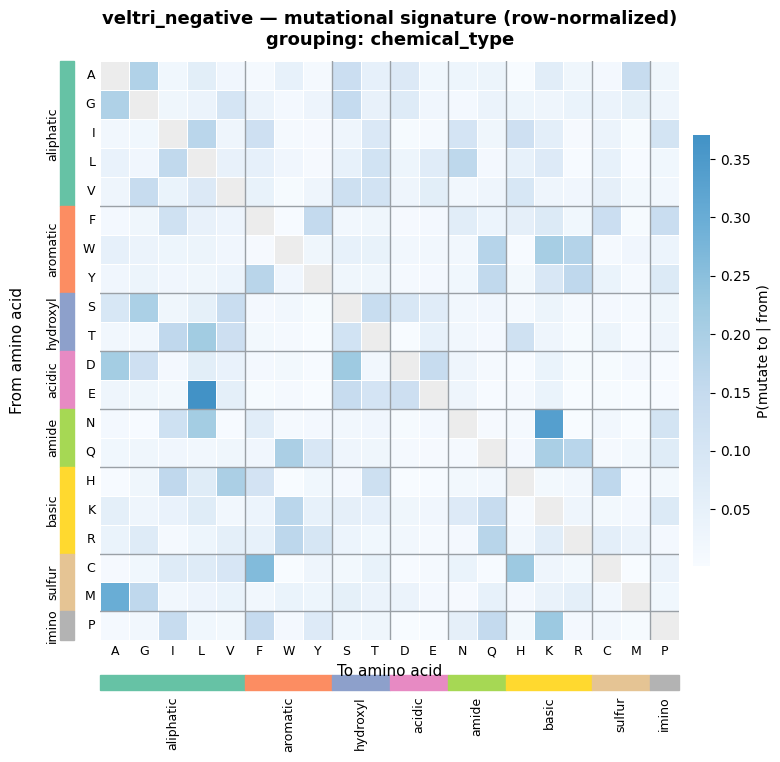

In [7]:
# Primary view: granular chemical_type grouping
plot_change_matrix(
    neg_matrix,
    classification=PRIMARY_CLASSIFICATION,
    title=(
        "veltri_negative — mutational signature (row-normalized)\n"
        f"grouping: {PRIMARY_CLASSIFICATION}"
    ),
    cbar_label="P(mutate to | from)",
)


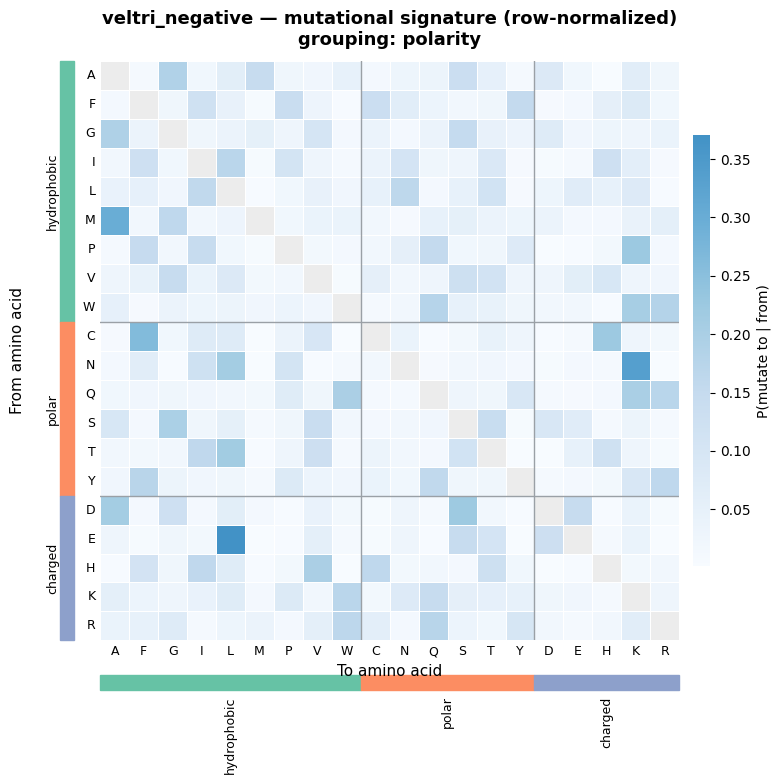

In [8]:
# Complementary coarse view: clean 3-block polarity grouping
plot_change_matrix(
    neg_matrix,
    classification="polarity",
    title=(
        "veltri_negative — mutational signature (row-normalized)\n"
        "grouping: polarity"
    ),
    cbar_label="P(mutate to | from)",
)


## Positive vs negative comparison

Compares the mutational signatures of `veltri_positive` and `veltri_negative` at the
same 0.001 / 0.1 threshold. This runs **only if** an enumerated `veltri_positive` mutants
CSV is present in the datasets folder; otherwise it prints a skip message so the notebook
still executes end-to-end.

To produce the positive mutants, run the single-position enumeration on
`results/data/veltri_positive.csv` and drop the output into `results/data/mutants/`.

In [9]:
# Guarded positive-vs-negative comparison
POS_PATTERN = "*veltri_positive*threshold=0.001_token_threshold=0.1*"
pos_path = select_dataset(POS_PATTERN)

if pos_path is None:
    print(
        "veltri_positive single-position mutants not found in\n"
        f"  {MUTANTS_DIR}\n"
        f"  (looked for: {POS_PATTERN!r})\n\n"
        "Skipping the positive-vs-negative comparison.\n"
        "Generate positive mutants from results/data/veltri_positive.csv into this "
        "folder, then re-run this cell."
    )
else:
    print(f"Using positive dataset:\n  {pos_path.name}")
    mutants_pos = pd.read_csv(pos_path)
    pos_matrix, _ = build_change_matrix(mutants_pos)

    for label, mat in [("veltri_negative", neg_matrix), ("veltri_positive", pos_matrix)]:
        plot_change_matrix(
            mat,
            classification=PRIMARY_CLASSIFICATION,
            title=f"{label} — mutational signature\ngrouping: {PRIMARY_CLASSIFICATION}",
            cbar_label="P(mutate to | from)",
        )

    diff = pos_matrix - neg_matrix
    vmax = float(np.nanmax(np.abs(diff.values)))
    plot_change_matrix(
        diff,
        classification=PRIMARY_CLASSIFICATION,
        cmap=SOFT_DIVERGING,
        title=f"Difference: positive − negative\ngrouping: {PRIMARY_CLASSIFICATION}",
        vmin=-vmax,
        vmax=vmax,
        cbar_label="Δ P(mutate to | from)",
    )


veltri_positive single-position mutants not found in
  C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\mutants
  (looked for: '*veltri_positive*threshold=0.001_token_threshold=0.1*')

Skipping the positive-vs-negative comparison.
Generate positive mutants from results/data/veltri_positive.csv into this folder, then re-run this cell.
